# Day 22 — Exercises: ML Workflow & Regression

This notebook contains the exercise solutions for Day 22:
1. **Train-Test Split**: Partitioning data into train and test subsets.
2. **Linear Regression**: Training a baseline Ordinary Least Squares (OLS) model.
3. **Regularization (Ridge/Lasso)**: Preventing overfitting using L1 and L2 penalties.
4. **Residual Analysis**: Evaluating model assumptions visually.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Generate synthetic linear dataset
np.random.seed(42)
X = np.random.randn(200, 3) * 5
# Target y = 3*X1 - 2*X2 + 0.5*X3 + noise
y = 3.0 * X[:, 0] - 2.0 * X[:, 1] + 0.5 * X[:, 2] + np.random.normal(0, 1.5, size=200)

# Train-test split (80% training, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (160, 3)
Testing set shape:  (40, 3)


In [2]:
# 2. Train baseline Ordinary Least Squares (OLS) Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions on test set
y_pred_lr = lr.predict(X_test)

# Metrics evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Ordinary Least Squares (OLS) ===")
print(f"Intercept: {lr.intercept_:.4f}")
print(f"Coefficients (X1, X2, X3): {lr.coef_}")
print(f"Test RMSE: {rmse_lr:.4f}")
print(f"Test R2:   {r2_lr:.4f}")

=== Ordinary Least Squares (OLS) ===
Intercept: 0.0735
Coefficients (X1, X2, X3): [ 2.98036312 -1.96197372  0.53514833]
Test RMSE: 1.3906
Test R2:   0.9931


In [3]:
# 3. Apply Regularization (Ridge & Lasso)
# Ridge (L2 penalty) - shrinks coefficients towards zero
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso (L1 penalty) - enforces sparsity (can make coefficients exactly zero)
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("=== Regularized Coefficients Comparison ===")
print(f"OLS:   {lr.coef_}")
print(f"Ridge: {ridge.coef_}")
print(f"Lasso: {lasso.coef_}")

print("\n=== Performance Evaluation ===")
print(f"Ridge Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f} | R2: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Lasso Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f} | R2: {r2_score(y_test, y_pred_lasso):.4f}")

=== Regularized Coefficients Comparison ===
OLS:   [ 2.98036312 -1.96197372  0.53514833]
Ridge: [ 2.97022387 -1.95728922  0.53382749]
Lasso: [ 2.92397459 -1.92689014  0.49364072]

=== Performance Evaluation ===
Ridge Test RMSE: 1.4045 | R2: 0.9930
Lasso Test RMSE: 1.5146 | R2: 0.9919


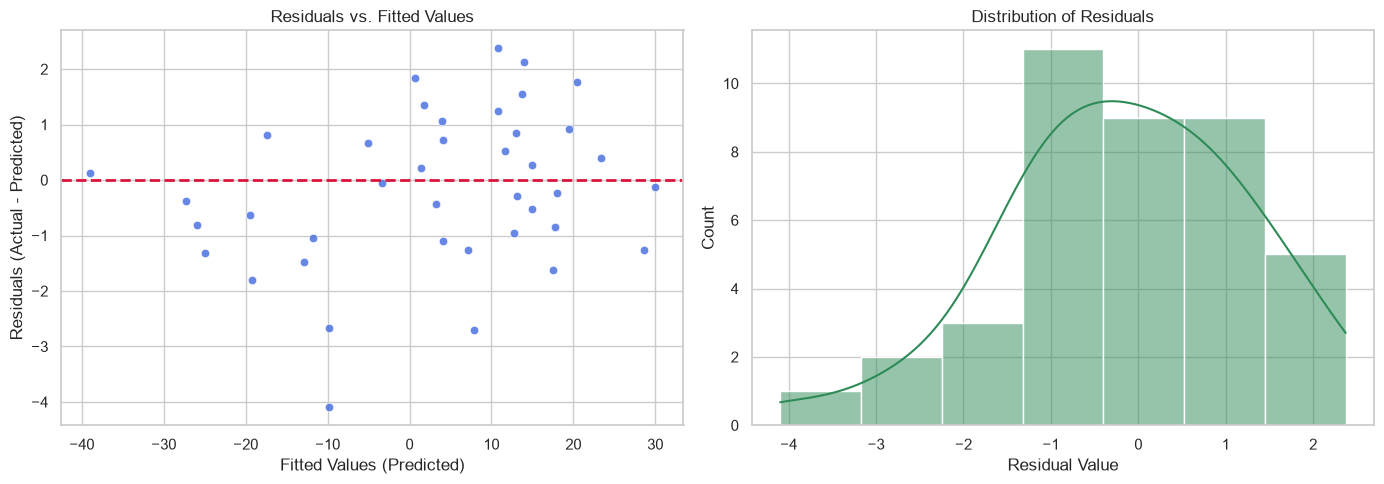

In [4]:
# 4. Generate Residual Plots
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Residuals vs. Fitted Values (Testing Homoscedasticity)
sns.scatterplot(x=y_pred_lr, y=residuals, ax=axes[0], color='royalblue', alpha=0.8)
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].set_xlabel('Fitted Values (Predicted)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# Histogram with KDE: Distribution of Residuals (Testing Normality)
sns.histplot(residuals, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Value')

plt.tight_layout()
plt.show()